In [5]:
%pip install pandas scikit-learn shap matplotlib

  Using cached shap-0.46.0.tar.gz (1.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached matplotlib-3.9.2-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.67.0-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.60.0.tar.gz (2.7 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [24 lines of output]
      Traceback (most recent call last):
        File "c:\Users\mhdas\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
          ~~~~^^
        File "c:\Users\mhdas\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\mhdas\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 118, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\mhdas\AppData\Local\Temp\pip-build-env-fs6evz1x\overlay\Lib\site-packa

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import re
import datetime
from scipy.stats import entropy

In [7]:
import pandas as pd

# Load the dataset
data = pd.read_csv(r"C:\Users\mhdas\Desktop\Minor Project\balanced_urls.csv")

In [8]:
# Inspect the dataset
print(data.head())
print(data.describe())

                         url   label  result
0     https://www.google.com  benign       0
1    https://www.youtube.com  benign       0
2   https://www.facebook.com  benign       0
3      https://www.baidu.com  benign       0
4  https://www.wikipedia.org  benign       0
         result
count  632508.0
mean        0.5
std         0.5
min         0.0
25%         0.0
50%         0.5
75%         1.0
max         1.0


In [9]:
import numpy as np
from scipy.stats import entropy
import pandas as pd

# Define suspicious keywords and URL shortening services
suspicious_keywords = [
    "login", "secure", "account", "update", "verify", "password",
    "confirm", "alert", "notification", "invoice", "payment",
    "claim", "reward", "bonus", "urgent", "click", "free", "offer",
    "win", "order", "gift", "support", "contact", "survey", "activate"
]

shortened_domains = [
    "bit.ly", "tinyurl.com", "goo.gl", "t.co", "is.gd",
    "buff.ly", "adf.ly", "ow.ly", "shorte.st", "lc.chat",
    "soo.gd", "qr.ae", "v.gd", "rb.gy", "cutt.ly", "po.st"
]


# Define a function to calculate Shannon entropy, which measures randomness in a URL
def calculate_entropy(url):
    # Probability of each character's appearance in the URL
    prob = [float(url.count(c)) / len(url) for c in dict.fromkeys(list(url))]
    # Calculate entropy using base 2
    return entropy(prob, base=2)


# Define a function to extract lexical features from each URL
def extract_lexical_features(url):
    url_lower = url.lower()  # Convert URL to lowercase to ensure case-insensitive keyword matching

    # Check if the URL contains any high-risk keywords
    contains_suspicious_words = int(any(keyword in url_lower for keyword in suspicious_keywords))

    # Calculate Shannon entropy only if suspicious keywords are present
    url_entropy = calculate_entropy(url) if contains_suspicious_words else 0

    # Extract various lexical features as a dictionary
    features = {
        "url_length": len(url),  # Total length of the URL
        "num_dots": url.count('.'),  # Count of dots, may indicate subdomains or IP addresses
        "num_slashes": url.count('/'),  # Count of slashes, indicating directory depth
        "num_digits": sum(c.isdigit() for c in url),  # Count of numeric characters in the URL
        "num_hyphens": url.count('-'),  # Count of hyphens, often used in phishing URLs
        "num_special_chars": sum(url.count(char) for char in ['-', '_', '=', '?', '&']),  # Count of special characters
        "subdomain_count": url.count('.') - 1,  # Approximate number of subdomains
        "https_present": int(url.startswith("https")),  # HTTPS presence as a binary indicator
        "num_tokens": len(url.split('/')),  # Count of tokens in the URL path
        "digit_to_char_ratio": sum(c.isdigit() for c in url) / len(url) if len(url) > 0 else 0,  # Ratio of digits to total URL length
        "contains_suspicious_words": contains_suspicious_words,  # Whether suspicious words are present
        "url_entropy": url_entropy,  # Shannon entropy of the URL
        "is_shortened_url": int(any(short_domain in url_lower for short_domain in shortened_domains)),  # Presence of URL shorteners
        "has_executable_extension": int(url_lower.endswith(('.exe', '.zip', '.scr', '.bat', '.dat', '.vbs')))  # Checks for executable extensions
    }
    # Convert the dictionary to a Pandas Series for easy concatenation
    return pd.Series(features)

# Apply the feature extraction function to each URL in the dataset
lexical_features = data['url'].apply(extract_lexical_features)

# Combine extracted lexical features with the main dataset
data = pd.concat([data, lexical_features], axis=1)

In [10]:
# Define the features (X) by excluding the 'url' and 'label' and 'result' from the feature set columns
X = data.drop(columns=['url', 'label', 'result'], errors='ignore')

# Define the target (y) as the 'result' column (which contains numerical values)
y = data['result']


In [11]:
# Combine 'https_present' with selected features cause https alone gives a large importance on prediction
# Step 1: Combine https_present with subdomain_count
X['https_subdomain'] = X['https_present'] * 0.001 + X['subdomain_count']
X['https_num_dots'] = X['https_present'] * 0.001 + X['num_dots']
X['https_num_digits'] = X['https_present'] * 0.001 + X['num_digits']
# Step 2: Remove the original https_present feature
X = X.drop(columns=['https_present'])



In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}, Testing set size: {len(X_test)}")

Training set size: 506006, Testing set size: 126502


In [13]:
'''from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming you already have your features (X) and target (y) ready

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [10, 15, 20],  # Test different depths
    'min_samples_split': [2, 5, 10, 20]  # Test various split values
}

# Create the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Use GridSearchCV for tuning hyperparameters
grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # Evaluation metric
    verbose=1  # Print progress
)

# Fit the model to the training data and search for the best parameters
grid_search.fit(X_train, y_train)

# Print the best parameters found during the search
print("Best Parameters:", grid_search.best_params_)

# Use the best model found by GridSearchCV for final training
rf_optimized = grid_search.best_estimator_

# Evaluate the final optimized model on the test set
final_accuracy = rf_optimized.score(X_test, y_test)
print(f"Final Model Accuracy: {final_accuracy}")'''

'from sklearn.model_selection import GridSearchCV\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import train_test_split\n\n# Assuming you already have your features (X) and target (y) ready\n\n# Split the data into training and testing sets\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n\n# Define the parameter grid for GridSearchCV\nparam_grid = {\n    \'max_depth\': [10, 15, 20],  # Test different depths\n    \'min_samples_split\': [2, 5, 10, 20]  # Test various split values\n}\n\n# Create the Random Forest model\nrf_model = RandomForestClassifier(random_state=42)\n\n# Use GridSearchCV for tuning hyperparameters\ngrid_search = GridSearchCV(\n    rf_model,\n    param_grid,\n    cv=3,  # 3-fold cross-validation\n    scoring=\'accuracy\',  # Evaluation metric\n    verbose=1  # Print progress\n)\n\n# Fit the model to the training data and search for the best parameters\ngrid_search.fit(X_train, y_train)\n\n

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model with optimal parameters
rf_model = RandomForestClassifier(max_depth=20, min_samples_split=10, random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


Accuracy: 0.9883875353749347
Precision: 0.9972685497605964
Recall: 0.9795003708554926
F1 Score: 0.9883046057083715
AUC-ROC Score: 0.9972330173053311


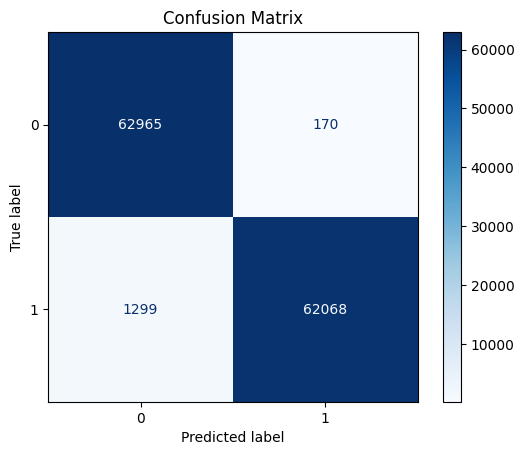

Classification Report:
               precision    recall  f1-score   support

      Benign       0.98      1.00      0.99     63135
   Malicious       1.00      0.98      0.99     63367

    accuracy                           0.99    126502
   macro avg       0.99      0.99      0.99    126502
weighted avg       0.99      0.99      0.99    126502



In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC-ROC Score:", roc_auc)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))


In [18]:
# Get feature importance scores
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance_df)

                      Feature  Importance
13            https_subdomain    0.273478
14             https_num_dots    0.245317
15           https_num_digits    0.165078
6             subdomain_count    0.070873
1                    num_dots    0.056485
3                  num_digits    0.043771
8         digit_to_char_ratio    0.032379
7                  num_tokens    0.021775
0                  url_length    0.019765
5           num_special_chars    0.019304
12   has_executable_extension    0.019005
2                 num_slashes    0.016126
4                 num_hyphens    0.006724
10                url_entropy    0.006074
9   contains_suspicious_words    0.002716
11           is_shortened_url    0.001130


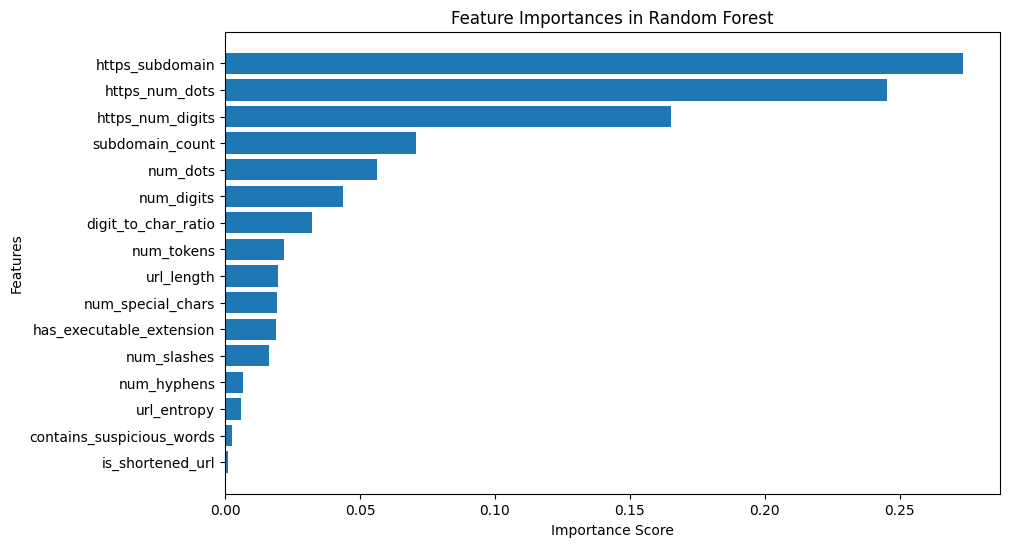

In [19]:
import matplotlib.pyplot as plt

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importances in Random Forest')
plt.gca().invert_yaxis()  # Flip to show highest importance on top
plt.show()

In [20]:
#Scoring system based on probability

from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# Step 1: Compute probability-based risk scores
y_prob = rf_model.predict_proba(X)[:, 1]  # Probability of being malicious (class 1)
probability_scores = pd.DataFrame({
    "probability_risk_score": y_prob
}, index=data.index)  # Align with dataset index

# Step 2: Define thresholds for risk classification
def classify_probability_risk(score):
    if score < 0.3:
        return "Low Risk"
    elif score < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

# Step 3: Apply classification to the probability scores
probability_scores['probability_risk_category'] = probability_scores['probability_risk_score'].apply(classify_probability_risk)

# Step 4: Add the scores and categories to the main dataset
data = pd.concat([data, probability_scores], axis=1)

# Display the updated dataset with classifications
print(data[['url', 'probability_risk_score', 'probability_risk_category']].head())

# Step 3: Concatenate the scores with the main dataset
data = pd.concat([data, probability_scores], axis=1)

                         url  probability_risk_score probability_risk_category
0     https://www.google.com                0.014873                  Low Risk
1    https://www.youtube.com                0.084573                  Low Risk
2   https://www.facebook.com                0.017369                  Low Risk
3      https://www.baidu.com                0.001117                  Low Risk
4  https://www.wikipedia.org                0.037065                  Low Risk


In [21]:
#Custom score based on weight for features

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Step 1: Normalize the features
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)  # Normalize the feature matrix

# Step 2: Define custom weights for features
feature_weights = {
    "url_length": 0.08,  # Reduced a bit as it's less directly indicative
    "num_dots": 0.06,  # Reduced as it has less direct relevance
    "num_slashes": 0.05,  # Reduced as it’s not as impactful
    "num_digits": 0.05,  # Reduced as it’s not as impactful
    "num_hyphens": 0.04,  # Reduced as it’s generally less relevant
    "num_special_chars": 0.06,  # Important but not as crucial as suspicious words
    "subdomain_count": 0.06,  # Reduced slightly
    "https_present": 0.10,  # Increased, important for distinguishing legit URLs
    "num_tokens": 0.05,  # Reduced
    "digit_to_char_ratio": 0.05,  # Reduced, lower importance
    "contains_suspicious_words": 0.20,  # Increased, very important for classification
    "url_entropy": 0.06,  # Slightly reduced, still somewhat useful
    "is_shortened_url": 0.05,  # Reduced, less important overall
    "has_executable_extension": 0.12,  # Increased, highly important for spotting malware
    "https_subdomain": 0.08,  # Important for phishing detection
    "https_num_digits": 0.06,  # Moderately important, adjusted
    "https_num_dots": 0.06   # Moderately important, adjusted
}


weights = np.array([feature_weights[feature] for feature in X.columns])

# Step 3: Define the custom scoring function
def compute_custom_score(normalized_features, weights):
    """
    Calculate the custom risk score using a linear combination of features.
    """
    return np.dot(normalized_features, weights)

# Step 4: Compute the custom risk scores for the dataset
custom_score = compute_custom_score(X_normalized, weights)

# Add the scores to the dataset
data['custom_score'] = custom_score

# Step 5: Categorize URLs based on scores (optional)
# Example: Define thresholds to classify risk levels
def classify_risk(score):
    if score < 0.3:
        return "Low Risk"
    elif score < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

# Apply the classification
data['risk_category'] = data['custom_score'].apply(classify_risk)

# Display results
print(data[['url', 'custom_score', 'risk_category']].head())

                         url  custom_score risk_category
0     https://www.google.com      0.017458      Low Risk
1    https://www.youtube.com      0.017493      Low Risk
2   https://www.facebook.com      0.017528      Low Risk
3      https://www.baidu.com      0.017424      Low Risk
4  https://www.wikipedia.org      0.017562      Low Risk
